# 🐘 Elephant Species Classification
## Deep Learning & Transfer Learning — End-to-End Pipeline

**Classes:** African Elephant | Asian Elephant  
**Pipeline:** Data → Augmentation → CNN (Baseline) → MobileNetV2 → HPO → Xception → Evaluation → MongoDB + MLflow Logging → Artifacts ZIP

## ⚙️ Phase 0 — Environment Setup & Secrets

In [1]:
# ── Install extra dependencies ────────────────────────────────────────────────
!pip install -q keras-tuner mlflow pymongo dagshub
print("✅ Packages installed.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 115.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9

In [2]:
import os
from google.colab import userdata

# ── MongoDB (from Colab Secrets) ──────────────────────────────────────────────
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# ── MLflow / DagsHub ──────────────────────────────────────────────────────────
USE_DAGSHUB = True  # ✅ set False to log locally

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('✅ Env vars set.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")


✅ Env vars set.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow


## 📦 Phase 1 — Imports & GPU Check

In [3]:
import os, json, time, zipfile, datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization,
                                     GlobalAveragePooling2D, GlobalMaxPooling2D)
from tensorflow.keras.applications import MobileNetV2, Xception
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau)
import keras_tuner as kt

import mlflow
import mlflow.tensorflow
from pymongo import MongoClient
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc)

# ── GPU check ────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print(f"🖥️  GPUs available: {len(gpus)}")
for g in gpus:
    print("  ", g)
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)


🖥️  GPUs available: 1
   PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 📁 Phase 2 — Paths, Output Directories & MongoDB Connection

In [5]:
# ── Dataset ZIPs already uploaded to /content ────────────────────────────────
import zipfile, os

TRAIN_ZIP = '/content/train-20260105T160050Z-1-001.zip'
TEST_ZIP  = '/content/test-20260105T160050Z-1-001.zip'
DATA_DIR  = '/content/data'

os.makedirs(DATA_DIR, exist_ok=True)

print('📦 Extracting train zip …')
with zipfile.ZipFile(TRAIN_ZIP, 'r') as z:
    z.extractall(DATA_DIR)
print('📦 Extracting test zip …')
with zipfile.ZipFile(TEST_ZIP, 'r') as z:
    z.extractall(DATA_DIR)

# ── Auto-detect extracted folder names ───────────────────────────────────────
# Handles both flat layout  (/content/data/train/African/…)
# and nested layout         (/content/data/train-…/train/African/…)
def _find_dir(base, name):
    """Return the first directory whose name equals `name` under `base`."""
    for root, dirs, _ in os.walk(base):
        for d in dirs:
            if d.lower() == name.lower():
                return os.path.join(root, d)
    return None

TRAIN_PATH = _find_dir(DATA_DIR, 'train')
TEST_PATH  = _find_dir(DATA_DIR, 'test')

assert TRAIN_PATH, '❌ Could not locate train folder after extraction'
assert TEST_PATH,  '❌ Could not locate test folder after extraction'

print(f'✅ TRAIN_PATH = {TRAIN_PATH}')
print(f'✅ TEST_PATH  = {TEST_PATH}')

# ── Local output directories ─────────────────────────────────────────────────
OUTPUT_DIR  = '/content/outputs'
PLOTS_DIR   = f'{OUTPUT_DIR}/plots'
MODELS_DIR  = f'{OUTPUT_DIR}/models'
REPORTS_DIR = f'{OUTPUT_DIR}/reports'

for d in [OUTPUT_DIR, PLOTS_DIR, MODELS_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

print('\n✅ Output directories ready:')
for d in [OUTPUT_DIR, PLOTS_DIR, MODELS_DIR, REPORTS_DIR]:
    print(f'   {d}')


📦 Extracting train zip …
📦 Extracting test zip …
✅ TRAIN_PATH = /content/data/train
✅ TEST_PATH  = /content/data/test

✅ Output directories ready:
   /content/outputs
   /content/outputs/plots
   /content/outputs/models
   /content/outputs/reports


In [6]:
# ── MongoDB connection ────────────────────────────────────────────────────────
def get_mongo_collection(db_name="elephant_clf", collection_name="experiments"):
    client = MongoClient(os.environ['MONGO_DB_URL'])
    return client[db_name][collection_name]

def log_to_mongo(collection, run_name, params, metrics, notes=""):
    doc = {
        "run_name"  : run_name,
        "timestamp" : datetime.datetime.utcnow().isoformat(),
        "params"    : params,
        "metrics"   : metrics,
        "notes"     : notes,
    }
    result = collection.insert_one(doc)
    print(f"   📦 MongoDB → inserted id: {result.inserted_id}")
    return str(result.inserted_id)

try:
    col = get_mongo_collection()
    print("✅ MongoDB connected.")
except Exception as e:
    print(f"⚠️  MongoDB connection failed: {e}")
    col = None


✅ MongoDB connected.


## 🗂️ Phase 3 — Data Loading & Augmentation

In [7]:
IMG_SIZE_224 = (224, 224)
IMG_SIZE_299 = (299, 299)
BATCH_SIZE   = 32

# ── Augmented train generator ─────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale          = 1./255,
    rotation_range   = 20,
    zoom_range       = 0.2,
    horizontal_flip  = True,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    shear_range        = 0.1,
)

# ── Validation generator (no augmentation) ───────────────────────────────────
test_datagen = ImageDataGenerator(rescale=1./255)

# ── 224×224 generators (CNN + MobileNetV2) ───────────────────────────────────
training_set = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE_224, batch_size=BATCH_SIZE, class_mode='categorical'
)
test_set = test_datagen.flow_from_directory(
    TEST_PATH, target_size=IMG_SIZE_224, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

CLASS_INDICES = training_set.class_indices
IDX_TO_CLASS  = {v: k for k, v in CLASS_INDICES.items()}
NUM_CLASSES   = training_set.num_classes

print(f"✅ Class indices : {CLASS_INDICES}")
print(f"   Train batches : {len(training_set)}  |  Test batches: {len(test_set)}")
print(f"   Train samples : {training_set.samples}  |  Test samples: {test_set.samples}")

# ── Save class_indices.json ───────────────────────────────────────────────────
with open(f'{OUTPUT_DIR}/class_indices.json', 'w') as f:
    json.dump(CLASS_INDICES, f)
print("   class_indices.json saved.")


Found 840 images belonging to 2 classes.
Found 188 images belonging to 2 classes.
✅ Class indices : {'African': 0, 'Asian': 1}
   Train batches : 27  |  Test batches: 6
   Train samples : 840  |  Test samples: 188
   class_indices.json saved.


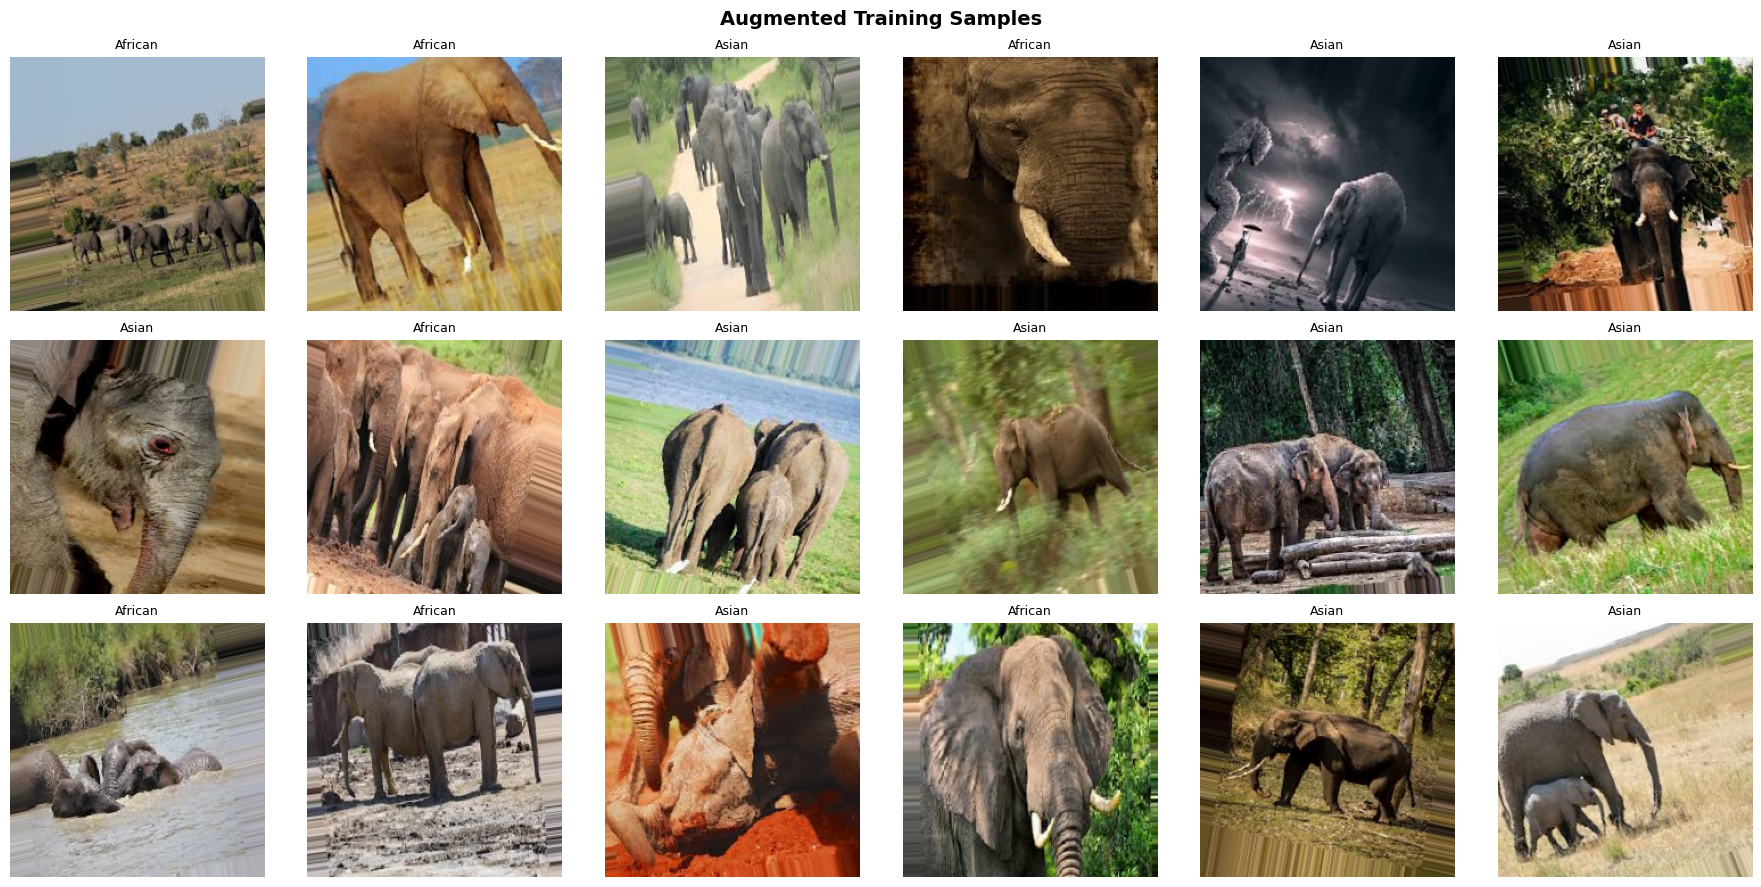

✅ Plot saved → 01_augmented_samples.png


In [8]:
# ── Visualise a batch of augmented images ─────────────────────────────────────
imgs, labels = next(training_set)
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.ravel()
for i in range(18):
    axes[i].imshow(imgs[i])
    axes[i].set_title(IDX_TO_CLASS[np.argmax(labels[i])], fontsize=9)
    axes[i].axis('off')
plt.suptitle('Augmented Training Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_augmented_samples.png', dpi=120)
plt.show()
print("✅ Plot saved → 01_augmented_samples.png")


## 🛠️ Utilities

In [9]:
def plot_history(history, title, save_path):
    """Plot and save training / validation curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Train Acc',  linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Acc',    linewidth=2, linestyle='--')
    ax1.set_title(f'{title} — Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
    ax2.set_title(f'{title} — Loss', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f"✅ Plot saved → {os.path.basename(save_path)}")


def evaluate_model(model, generator, model_name, save_prefix, preprocess_fn=None):
    """Full evaluation: loss/acc, classification report, confusion matrix, ROC."""
    generator.reset()

    # Predictions ────────────────────────────────────────────
    preds_proba = model.predict(generator, verbose=1)
    y_pred      = np.argmax(preds_proba, axis=1)
    y_true      = generator.classes

    # Metrics ────────────────────────────────────────────────
    loss, acc = model.evaluate(generator, verbose=0)
    report    = classification_report(y_true, y_pred,
                                      target_names=list(IDX_TO_CLASS.values()),
                                      output_dict=True)
    print(f"\n📊 {model_name}  |  Loss: {loss:.4f}  |  Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=list(IDX_TO_CLASS.values())))

    # Save text report ────────────────────────────────────────
    report_path = f'{REPORTS_DIR}/{save_prefix}_report.txt'
    with open(report_path, 'w') as f:
        f.write(f"{model_name}\nLoss: {loss:.4f}  Accuracy: {acc:.4f}\n\n")
        f.write(classification_report(y_true, y_pred,
                                      target_names=list(IDX_TO_CLASS.values())))
    print(f"   📄 Report → {os.path.basename(report_path)}")

    # Confusion matrix ────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=list(IDX_TO_CLASS.values()),
                yticklabels=list(IDX_TO_CLASS.values()))
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    # ROC (binary) ────────────────────────────────────────────
    if NUM_CLASSES == 2:
        fpr, tpr, _ = roc_curve(y_true, preds_proba[:, 1])
        roc_auc     = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}', color='darkorange')
        axes[1].plot([0,1],[0,1],'k--', lw=1)
        axes[1].set_title(f'{model_name}\nROC Curve', fontweight='bold')
        axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
        axes[1].legend(); axes[1].grid(True, alpha=0.3)
    else:
        axes[1].axis('off')

    plt.tight_layout()
    cm_path = f'{PLOTS_DIR}/{save_prefix}_eval.png'
    plt.savefig(cm_path, dpi=120)
    plt.show()
    print(f"   📊 Eval plot → {os.path.basename(cm_path)}")

    return {"loss": round(loss, 4), "accuracy": round(acc, 4),
            "classification_report": report}


def log_experiment(run_name, model, history, metrics, params, tags=None):
    """Log to both MLflow and MongoDB."""
    mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])
    mlflow.set_experiment("Elephant-Species-Classification")

    with mlflow.start_run(run_name=run_name, tags=tags or {}):
        mlflow.log_params(params)
        # Log epoch-level metrics
        for epoch, (ta, va, tl, vl) in enumerate(zip(
                history.history['accuracy'],
                history.history['val_accuracy'],
                history.history['loss'],
                history.history['val_loss'])):
            mlflow.log_metric("train_accuracy", ta, step=epoch)
            mlflow.log_metric("val_accuracy",   va, step=epoch)
            mlflow.log_metric("train_loss",     tl, step=epoch)
            mlflow.log_metric("val_loss",       vl, step=epoch)
        # Final metrics
        for k, v in metrics.items():
            if isinstance(v, (int, float)):
                mlflow.log_metric(k, v)
        # Plots as artifacts
        for f in os.listdir(PLOTS_DIR):
            mlflow.log_artifact(f'{PLOTS_DIR}/{f}', artifact_path='plots')
        # Reports
        for f in os.listdir(REPORTS_DIR):
            mlflow.log_artifact(f'{REPORTS_DIR}/{f}', artifact_path='reports')
        run_id = mlflow.active_run().info.run_id
    print(f"✅ MLflow run logged  →  run_id: {run_id}")

    # MongoDB
    if col is not None:
        log_to_mongo(col, run_name, params, metrics)

    return run_id

print("✅ Utility functions defined.")


✅ Utility functions defined.


## 🧱 Phase 4 — Baseline Custom CNN

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model_cnn = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(), MaxPooling2D((2,2)),
    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(), MaxPooling2D((2,2)),
    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(), MaxPooling2D((2,2)),
    # Block 4
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(), MaxPooling2D((2,2)),
    # Dense head
    Flatten(),
    Dense(256, activation='relu'), Dropout(0.5),
    Dense(128, activation='relu'), Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax'),
])

model_cnn.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
model_cnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,860,930 (37.62 MB)

 Trainable params: 9,859,970 (37.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
cnn_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(f'{MODELS_DIR}/baseline_cnn_best.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]

print("🚀 Training Baseline CNN …")
history_cnn = model_cnn.fit(
    training_set,
    validation_data=test_set,
    epochs=30,
    callbacks=cnn_callbacks,
)


🚀 Training Baseline CNN …
Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.5143 - loss: 6.4287
Epoch 1: val_accuracy improved from None to 0.51596, saving model to /content/outputs/models/baseline_cnn_best.h5



Epoch 1: finished saving model to /content/outputs/models/baseline_cnn_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 41s 849ms/step - accuracy: 0.5071 - loss: 6.5653 - val_accuracy: 0.5160 - val_loss: 2.3401 - learning_rate: 0.0010
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.4868 - loss: 7.0527
Epoch 2: val_accuracy did not improve from 0.51596
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 583ms/step - accuracy: 0.4964 - loss: 6.4897 - val_accuracy: 0.5160 - val_loss: 2.5559 - learning_rate: 0.0010
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.5458 - loss: 4.5660
Epoch 3: val_accuracy did not improve from 0.51596
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 491ms/step - accuracy: 0.5381 - loss: 4.1699 - val_accuracy: 0.4574 - val_loss: 1.0536 - learning_rate: 0.0010
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.4947 - loss: 3.9754
Epoch 4: val_accuracy did not improve from 0.51596
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 487ms/step - accuracy: 0.4798 - loss: 4.0703 - val_a

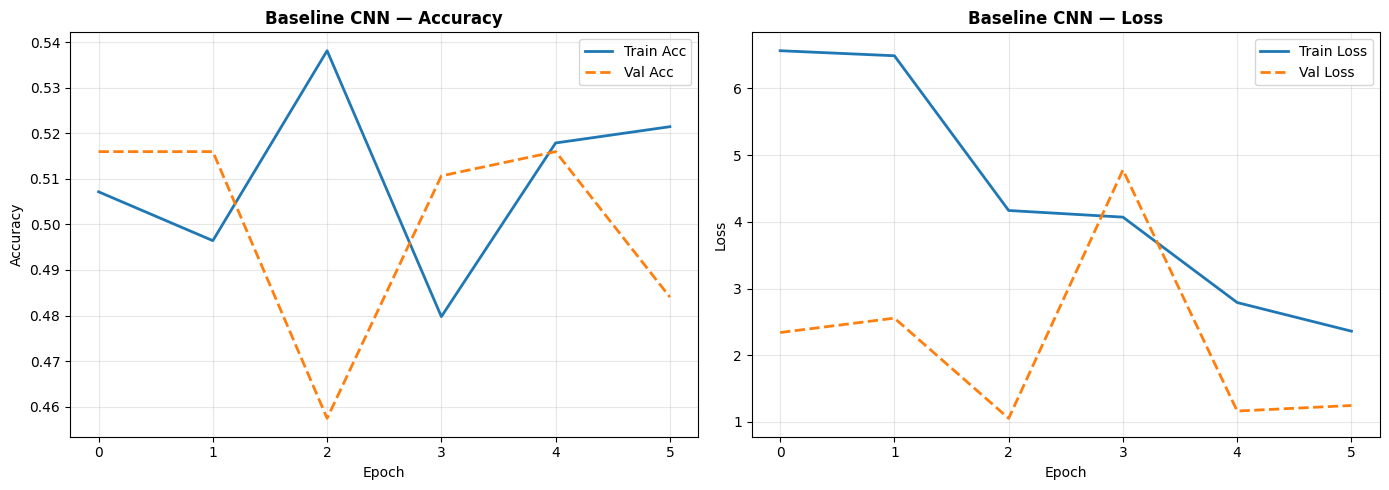

✅ Plot saved → 02_cnn_history.png
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 482ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


📊 Baseline CNN  |  Loss: 2.3401  |  Accuracy: 0.5160
              precision    recall  f1-score   support

     African       0.52      1.00      0.68        97
       Asian       0.00      0.00      0.00        91

    accuracy                           0.52       188
   macro avg       0.26      0.50      0.34       188
weighted avg       0.27      0.52      0.35       188

   📄 Report → cnn_report.txt


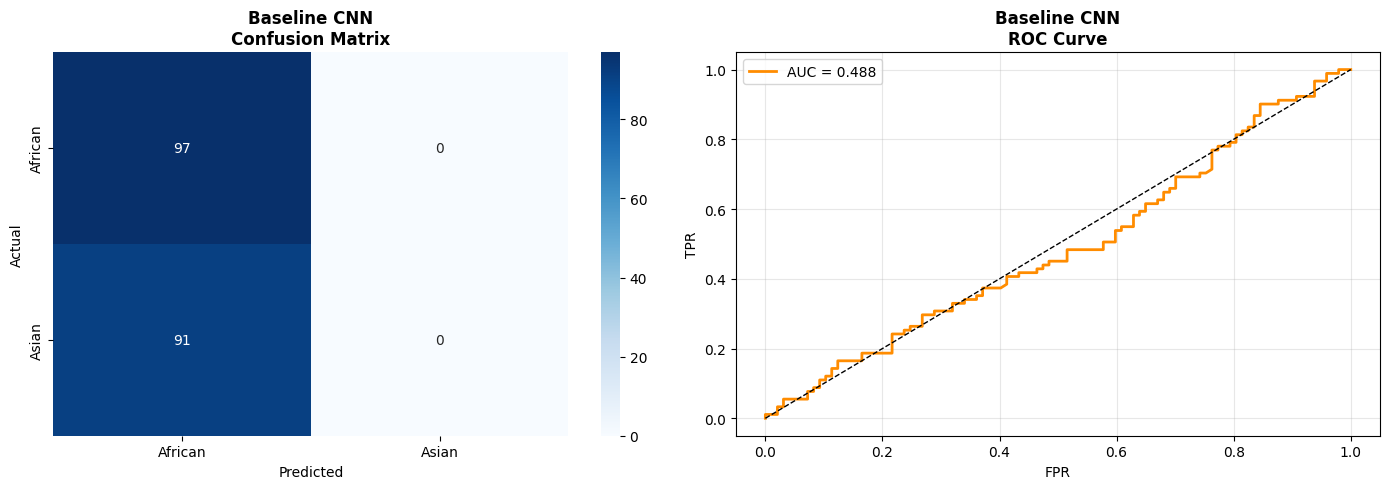

   📊 Eval plot → cnn_eval.png


2026/04/22 06:04:28 INFO mlflow.tracking.fluent: Experiment with name 'Elephant-Species-Classification' does not exist. Creating a new experiment.


🏃 View run Baseline_CNN at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/14/runs/886c98b14737441eaf83b9ec60579496
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/14
✅ MLflow run logged  →  run_id: 886c98b14737441eaf83b9ec60579496


/tmp/ipykernel_3960/1037193562.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp" : datetime.datetime.utcnow().isoformat(),


   📦 MongoDB → inserted id: 69e86507d96344abaef67ffe
✅ Phase 4 complete. Best val_acc = 0.5160


In [12]:
plot_history(history_cnn, 'Baseline CNN', f'{PLOTS_DIR}/02_cnn_history.png')
metrics_cnn = evaluate_model(model_cnn, test_set, 'Baseline CNN', 'cnn')

run_id_cnn = log_experiment(
    run_name = 'Baseline_CNN',
    model    = model_cnn,
    history  = history_cnn,
    metrics  = metrics_cnn,
    params   = {'model':'Custom CNN','epochs':30,'optimizer':'adam','batch_size':BATCH_SIZE},
    tags     = {'phase':'baseline'},
)
print(f"✅ Phase 4 complete. Best val_acc = {max(history_cnn.history['val_accuracy']):.4f}")


## 🚀 Phase 5 — Transfer Learning: MobileNetV2

In [13]:
base_mob = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_mob.trainable = False          # freeze base

x = base_mob.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
out_mob = Dense(NUM_CLASSES, activation='softmax')(x)

model_mob = Model(inputs=base_mob.input, outputs=out_mob)
model_mob.compile(optimizer=Adam(1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
model_mob.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,434 (9.87 MB)

 Trainable params: 328,450 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
mob_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(f'{MODELS_DIR}/mobilenetv2_best.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]

print("🚀 Training MobileNetV2 (frozen base) …")
history_mob = model_mob.fit(
    training_set,
    validation_data=test_set,
    epochs=20,
    callbacks=mob_callbacks,
)


🚀 Training MobileNetV2 (frozen base) …
Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.5466 - loss: 0.8253
Epoch 1: val_accuracy improved from None to 0.64894, saving model to /content/outputs/models/mobilenetv2_best.h5



Epoch 1: finished saving model to /content/outputs/models/mobilenetv2_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.5464 - loss: 0.7971 - val_accuracy: 0.6489 - val_loss: 0.6217 - learning_rate: 1.0000e-04
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.6615 - loss: 0.6489
Epoch 2: val_accuracy improved from 0.64894 to 0.72340, saving model to /content/outputs/models/mobilenetv2_best.h5



Epoch 2: finished saving model to /content/outputs/models/mobilenetv2_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 485ms/step - accuracy: 0.6619 - loss: 0.6628 - val_accuracy: 0.7234 - val_loss: 0.5336 - learning_rate: 1.0000e-04
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.6433 - loss: 0.6209
Epoch 3: val_accuracy improved from 0.72340 to 0.78723, saving model to /content/outputs/models/mobilenetv2_best.h5



Epoch 3: finished saving model to /content/outputs/models/mobilenetv2_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 479ms/step - accuracy: 0.6607 - loss: 0.6192 - val_accuracy: 0.7872 - val_loss: 0.5057 - learning_rate: 1.0000e-04
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.6811 - loss: 0.6175
Epoch 4: val_accuracy improved from 0.78723 to 0.80319, saving model to /content/outputs/models/mobilenetv2_best.h5



Epoch 4: finished saving model to /content/outputs/models/mobilenetv2_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 485ms/step - accuracy: 0.6869 - loss: 0.5995 - val_accuracy: 0.8032 - val_loss: 0.4909 - learning_rate: 1.0000e-04
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.7159 - loss: 0.5736
Epoch 5: val_accuracy improved from 0.80319 to 0.80851, saving model to /content/outputs/models/mobilenetv2_best.h5



Epoch 5: finished saving model to /content/outputs/models/mobilenetv2_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 492ms/step - accuracy: 0.7143 - loss: 0.5700 - val_accuracy: 0.8085 - val_loss: 0.4662 - learning_rate: 1.0000e-04
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.7264 - loss: 0.5636
Epoch 6: val_accuracy did not improve from 0.80851
27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 527ms/step - accuracy: 0.7274 - loss: 0.5567 - val_accuracy: 0.8085 - val_loss: 0.4415 - learning_rate: 1.0000e-04
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.7403 - loss: 0.5252
Epoch 7: val_accuracy improved from 0.80851 to 0.82447, saving model to /content/outputs/models/mobilenetv2_best.h5



Epoch 7: finished saving model to /content/outputs/models/mobilenetv2_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 485ms/step - accuracy: 0.7190 - loss: 0.5443 - val_accuracy: 0.8245 - val_loss: 0.4299 - learning_rate: 1.0000e-04
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.7373 - loss: 0.5255
Epoch 8: val_accuracy improved from 0.82447 to 0.82979, saving model to /content/outputs/models/mobilenetv2_best.h5



Epoch 8: finished saving model to /content/outputs/models/mobilenetv2_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 476ms/step - accuracy: 0.7190 - loss: 0.5357 - val_accuracy: 0.8298 - val_loss: 0.4261 - learning_rate: 1.0000e-04
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.7313 - loss: 0.5608
Epoch 9: val_accuracy improved from 0.82979 to 0.83511, saving model to /content/outputs/models/mobilenetv2_best.h5



Epoch 9: finished saving model to /content/outputs/models/mobilenetv2_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 474ms/step - accuracy: 0.7286 - loss: 0.5588 - val_accuracy: 0.8351 - val_loss: 0.4200 - learning_rate: 1.0000e-04
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.7551 - loss: 0.5247
Epoch 10: val_accuracy improved from 0.83511 to 0.86170, saving model to /content/outputs/models/mobilenetv2_best.h5



Epoch 10: finished saving model to /content/outputs/models/mobilenetv2_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 489ms/step - accuracy: 0.7512 - loss: 0.5251 - val_accuracy: 0.8617 - val_loss: 0.4020 - learning_rate: 1.0000e-04
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.7313 - loss: 0.5617
Epoch 11: val_accuracy did not improve from 0.86170
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 476ms/step - accuracy: 0.7464 - loss: 0.5299 - val_accuracy: 0.8564 - val_loss: 0.4024 - learning_rate: 1.0000e-04
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.7741 - loss: 0.4838
Epoch 12: val_accuracy did not improve from 0.86170
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 479ms/step - accuracy: 0.7726 - loss: 0.4980 - val_accuracy: 0.8404 - val_loss: 0.4093 - learning_rate: 1.0000e-04
Epoch 13/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.7451 - loss: 0.5144
Epoch 13: val_accuracy did not improve from 0.86170
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 469ms/step - accuracy: 0.7536 - lo

In [15]:
# ── Fine-tuning: unfreeze top 30 layers ──────────────────────────────────────
for layer in base_mob.layers[-30:]:
    layer.trainable = True

model_mob.compile(optimizer=Adam(1e-5),    # lower LR for fine-tuning
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("🔓 Fine-tuning top 30 layers of MobileNetV2 …")
history_mob_ft = model_mob.fit(
    training_set,
    validation_data=test_set,
    epochs=10,
    callbacks=mob_callbacks,
)


🔓 Fine-tuning top 30 layers of MobileNetV2 …
Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.6625 - loss: 0.6146
Epoch 1: val_accuracy did not improve from 0.86170
27/27 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.6810 - loss: 0.5988 - val_accuracy: 0.8351 - val_loss: 0.4123 - learning_rate: 1.0000e-05
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.6801 - loss: 0.5920
Epoch 2: val_accuracy did not improve from 0.86170
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 480ms/step - accuracy: 0.6917 - loss: 0.5893 - val_accuracy: 0.8351 - val_loss: 0.4134 - learning_rate: 1.0000e-05
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.7139 - loss: 0.5646
Epoch 3: val_accuracy did not improve from 0.86170

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 482ms/step - accuracy: 0.7119 - loss: 0.5667 - val_accuracy: 0.8457 - val_loss: 0.4059 - learning_rate: 1.0000e-05
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━

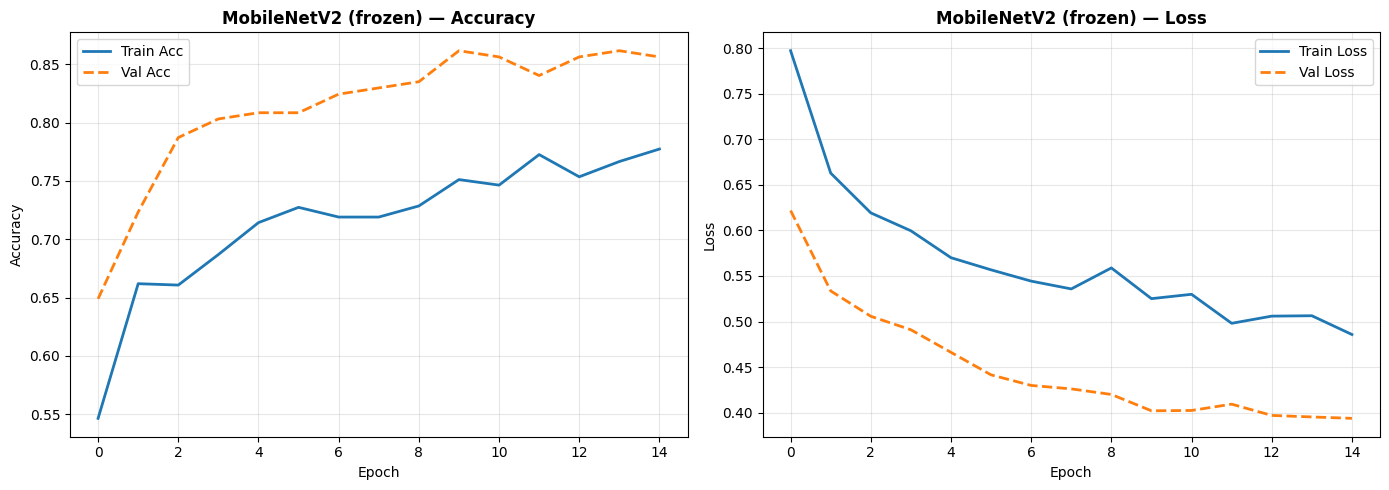

✅ Plot saved → 03_mob_frozen_history.png


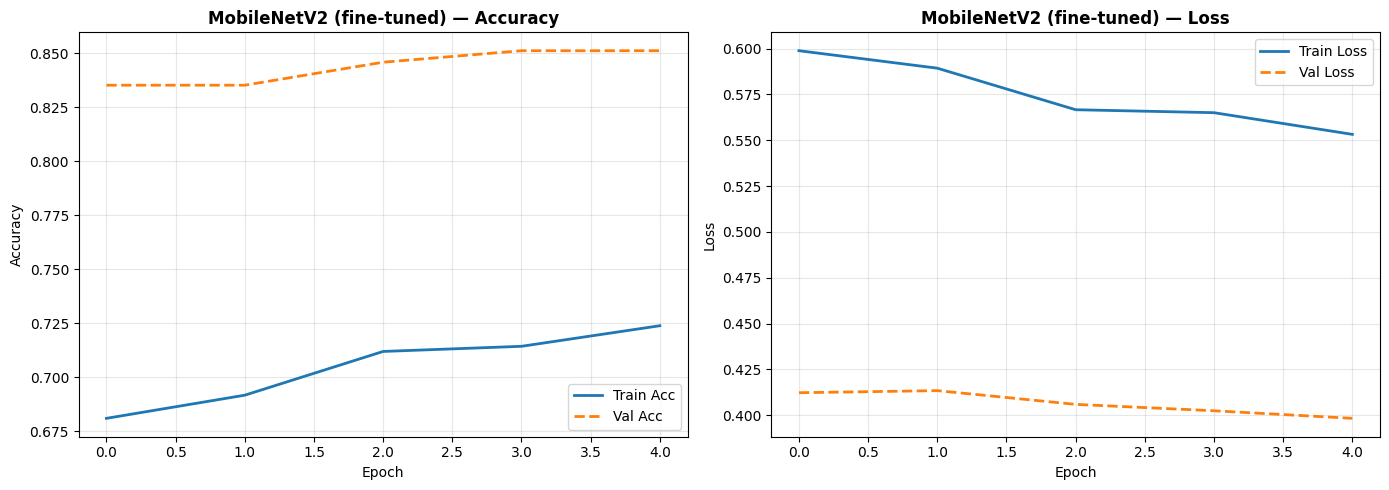

✅ Plot saved → 04_mob_ft_history.png
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step

📊 MobileNetV2  |  Loss: 0.4123  |  Accuracy: 0.8351
              precision    recall  f1-score   support

     African       0.78      0.94      0.85        97
       Asian       0.92      0.73      0.81        91

    accuracy                           0.84       188
   macro avg       0.85      0.83      0.83       188
weighted avg       0.85      0.84      0.83       188

   📄 Report → mobilenetv2_report.txt


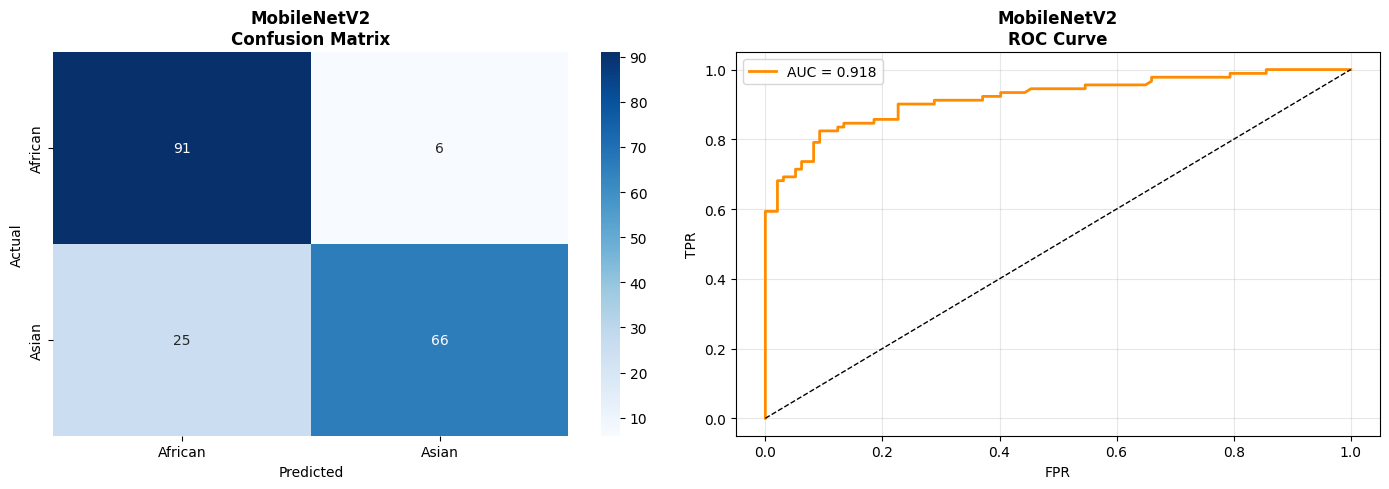

   📊 Eval plot → mobilenetv2_eval.png
✅ Weights saved → best_mobilenetv2.weights.h5
🏃 View run MobileNetV2_FineTuned at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/14/runs/0da6e5de8596469ebe940afa177a878c
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/14
✅ MLflow run logged  →  run_id: 0da6e5de8596469ebe940afa177a878c


/tmp/ipykernel_3960/1037193562.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp" : datetime.datetime.utcnow().isoformat(),


   📦 MongoDB → inserted id: 69e866a1d96344abaef67fff
✅ Phase 5 complete. Best val_acc = 0.8511


In [16]:
plot_history(history_mob,    'MobileNetV2 (frozen)',     f'{PLOTS_DIR}/03_mob_frozen_history.png')
plot_history(history_mob_ft, 'MobileNetV2 (fine-tuned)', f'{PLOTS_DIR}/04_mob_ft_history.png')

metrics_mob = evaluate_model(model_mob, test_set, 'MobileNetV2', 'mobilenetv2')

# Save weights for deployment (Streamlit app)
model_mob.save_weights(f'{MODELS_DIR}/best_mobilenetv2.weights.h5')
print("✅ Weights saved → best_mobilenetv2.weights.h5")

run_id_mob = log_experiment(
    run_name = 'MobileNetV2_FineTuned',
    model    = model_mob,
    history  = history_mob_ft,
    metrics  = metrics_mob,
    params   = {'model':'MobileNetV2','frozen_epochs':20,'ft_epochs':10,
                'optimizer':'Adam','lr_frozen':1e-4,'lr_ft':1e-5,'batch_size':BATCH_SIZE},
    tags     = {'phase':'transfer_learning'},
)
print(f"✅ Phase 5 complete. Best val_acc = {max(history_mob_ft.history['val_accuracy']):.4f}")


## 🔬 Phase 6 — Hyperparameter Optimisation (KerasTuner)

In [17]:
def build_model_hp(hp):
    base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)

    dense_units   = hp.Int('dense_units',   min_value=128, max_value=512, step=64)
    dropout_rate  = hp.Float('dropout_rate', min_value=0.2, max_value=0.6, step=0.1)
    learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-3, sampling='log')

    x   = Dense(dense_units, activation='relu')(x)
    x   = Dropout(dropout_rate)(x)
    out = Dense(NUM_CLASSES, activation='softmax')(x)

    m = Model(inputs=base.input, outputs=out)
    m.compile(optimizer=Adam(learning_rate),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m

tuner = kt.RandomSearch(
    build_model_hp,
    objective          = 'val_accuracy',
    max_trials         = 10,
    executions_per_trial = 1,
    directory          = '/content/tuner_dir',
    project_name       = 'mobilenetv2_hpo',
    overwrite          = True,
)

early_stop_hpo = EarlyStopping(monitor='val_accuracy', patience=4,
                               restore_best_weights=True)

print("🔍 Starting KerasTuner RandomSearch (10 trials) …")
tuner.search(
    training_set,
    validation_data = test_set,
    epochs          = 15,
    callbacks       = [early_stop_hpo],
    verbose         = 1,
)

best_hp  = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n🏆 Best Hyperparameters:")
print(json.dumps(best_hp.values, indent=2))


Trial 10 Complete [00h 03m 38s]
val_accuracy: 0.835106372833252

Best val_accuracy So Far: 0.8776595592498779
Total elapsed time: 00h 35m 16s

🏆 Best Hyperparameters:
{
  "dense_units": 192,
  "dropout_rate": 0.30000000000000004,
  "learning_rate": 0.0005018201348461449
}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


📊 Best HPO model evaluation:


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step

📊 MobileNetV2-HPO  |  Loss: 0.3630  |  Accuracy: 0.8777
              precision    recall  f1-score   support

     African       0.88      0.89      0.88        97
       Asian       0.88      0.87      0.87        91

    accuracy                           0.88       188
   macro avg       0.88      0.88      0.88       188
weighted avg       0.88      0.88      0.88       188

   📄 Report → hpo_report.txt


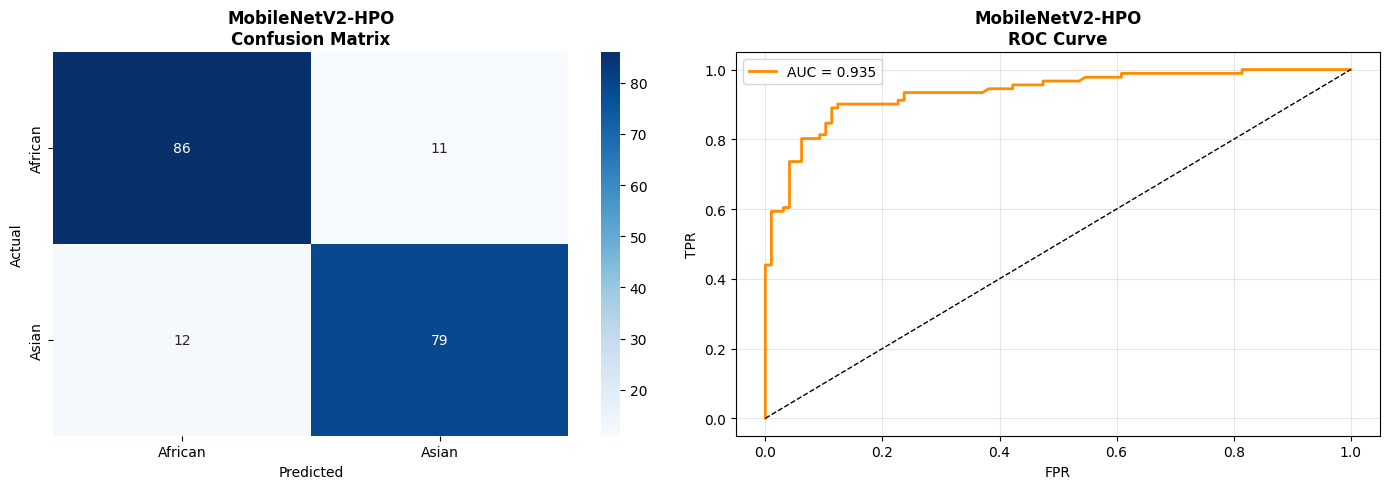

   📊 Eval plot → hpo_eval.png
✅ HPO weights saved.
🏃 View run MobileNetV2_HPO at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/14/runs/4557ad8db579440b8ad1932f6dbd9221
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/14
✅ MLflow run logged  →  run_id: 4557ad8db579440b8ad1932f6dbd9221


/tmp/ipykernel_3960/1037193562.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp" : datetime.datetime.utcnow().isoformat(),


   📦 MongoDB → inserted id: 69e86f0dd96344abaef68000
✅ Phase 6 complete.


In [18]:
# ── Retrieve best model & final evaluation ────────────────────────────────────
best_model_hpo = tuner.get_best_models(num_models=1)[0]

print("📊 Best HPO model evaluation:")
metrics_hpo = evaluate_model(best_model_hpo, test_set, 'MobileNetV2-HPO', 'hpo')

# Save weights
best_model_hpo.save_weights(f'{MODELS_DIR}/best_mobilenetv2_hpo.weights.h5')
print("✅ HPO weights saved.")

run_id_hpo = log_experiment(
    run_name = 'MobileNetV2_HPO',
    model    = best_model_hpo,
    history  = type('H', (), {'history': {
        'accuracy'    : [metrics_hpo['accuracy']],
        'val_accuracy': [metrics_hpo['accuracy']],
        'loss'        : [metrics_hpo['loss']],
        'val_loss'    : [metrics_hpo['loss']],
    }})(),
    metrics  = metrics_hpo,
    params   = {**best_hp.values, 'model':'MobileNetV2-HPO',
                'max_trials':10, 'batch_size':BATCH_SIZE},
    tags     = {'phase':'hpo'},
)
print(f"✅ Phase 6 complete.")


## ⚡ Phase 7 — Transfer Learning: Xception

In [ ]:
# ── 299×299 generators for Xception ─────────────────────────────────────────
train_datagen_xc = ImageDataGenerator(
    preprocessing_function = xception_preprocess,
    rotation_range   = 20,
    zoom_range       = 0.2,
    horizontal_flip  = True,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
)
test_datagen_xc = ImageDataGenerator(preprocessing_function=xception_preprocess)

training_set_xc = train_datagen_xc.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE_299, batch_size=BATCH_SIZE, class_mode='categorical'
)
test_set_xc = test_datagen_xc.flow_from_directory(
    TEST_PATH, target_size=IMG_SIZE_299, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
print("✅ Xception generators ready.")


In [20]:
base_xc = Xception(input_shape=(299,299,3), include_top=False, weights='imagenet')
base_xc.trainable = False

x_xc  = base_xc.output
x_xc  = GlobalMaxPooling2D()(x_xc)
x_xc  = Dense(256, activation='relu')(x_xc)
x_xc  = Dropout(0.4)(x_xc)
out_xc = Dense(NUM_CLASSES, activation='softmax')(x_xc)

model_xc = Model(inputs=base_xc.input, outputs=out_xc)
model_xc.compile(optimizer=Adam(1e-4),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
model_xc.summary()


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 74, 74,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add[0][0]       

 Total params: 21,386,538 (81.58 MB)

 Trainable params: 525,058 (2.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [21]:
xc_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(f'{MODELS_DIR}/xception_best.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]

print("🚀 Training Xception …")
history_xc = model_xc.fit(
    training_set_xc,
    validation_data = test_set_xc,
    epochs          = 10,
    callbacks       = xc_callbacks,
)


🚀 Training Xception …
Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5996 - loss: 0.8647
Epoch 1: val_accuracy improved from None to 0.85638, saving model to /content/outputs/models/xception_best.h5



Epoch 1: finished saving model to /content/outputs/models/xception_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.6321 - loss: 0.8217 - val_accuracy: 0.8564 - val_loss: 0.3770 - learning_rate: 1.0000e-04
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.6635 - loss: 0.7554
Epoch 2: val_accuracy improved from 0.85638 to 0.89894, saving model to /content/outputs/models/xception_best.h5



Epoch 2: finished saving model to /content/outputs/models/xception_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 916ms/step - accuracy: 0.6952 - loss: 0.6913 - val_accuracy: 0.8989 - val_loss: 0.3455 - learning_rate: 1.0000e-04
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.7032 - loss: 0.6451
Epoch 3: val_accuracy did not improve from 0.89894
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 888ms/step - accuracy: 0.7179 - loss: 0.6159 - val_accuracy: 0.8777 - val_loss: 0.3475 - learning_rate: 1.0000e-04
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.7218 - loss: 0.5958
Epoch 4: val_accuracy did not improve from 0.89894
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 879ms/step - accuracy: 0.7333 - loss: 0.5672 - val_accuracy: 0.8830 - val_loss: 0.3360 - learning_rate: 1.0000e-04
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.7858 - loss: 0.5300
Epoch 5: val_accuracy did not improve from 0.89894
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 883ms/step - accuracy: 0.7643 - loss: 0.5674

In [ ]:
plot_history(history_xc, 'Xception', f'{PLOTS_DIR}/05_xception_history.png')
metrics_xc = evaluate_model(model_xc, test_set_xc, 'Xception', 'xception')

model_xc.save_weights(f'{MODELS_DIR}/best_xception.weights.h5')
print("✅ Xception weights saved.")

run_id_xc = log_experiment(
    run_name = 'Xception_Transfer',
    model    = model_xc,
    history  = history_xc,
    metrics  = metrics_xc,
    params   = {'model':'Xception','epochs':20,'optimizer':'Adam',
                'lr':1e-4,'batch_size':BATCH_SIZE,'img_size':299},
    tags     = {'phase':'xception'},
)
print(f"✅ Phase 7 complete. Best val_acc = {max(history_xc.history['val_accuracy']):.4f}")


## 📊 Phase 8 — Model Comparison & Summary

In [ ]:
# ── Side-by-side bar chart ────────────────────────────────────────────────────
model_names  = ['Baseline CNN', 'MobileNetV2', 'MobileNetV2-HPO', 'Xception']
accuracies   = [
    metrics_cnn['accuracy'],
    metrics_mob['accuracy'],
    metrics_hpo['accuracy'],
    metrics_xc['accuracy'],
]
losses = [
    metrics_cnn['loss'],
    metrics_mob['loss'],
    metrics_hpo['loss'],
    metrics_xc['loss'],
]

x_pos = np.arange(len(model_names))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

bars1 = ax1.bar(x_pos, accuracies, color=['#4C72B0','#DD8452','#55A868','#C44E52'],
                width=0.5, edgecolor='white')
ax1.set_xticks(x_pos); ax1.set_xticklabels(model_names, rotation=15, ha='right')
ax1.set_ylim(0, 1.05); ax1.set_ylabel('Accuracy'); ax1.set_title('Test Accuracy Comparison', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

bars2 = ax2.bar(x_pos, losses, color=['#4C72B0','#DD8452','#55A868','#C44E52'],
                width=0.5, edgecolor='white')
ax2.set_xticks(x_pos); ax2.set_xticklabels(model_names, rotation=15, ha='right')
ax2.set_ylabel('Loss'); ax2.set_title('Test Loss Comparison', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, losses):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Elephant Species Classification — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/06_model_comparison.png', dpi=120)
plt.show()
print("✅ Comparison plot saved → 06_model_comparison.png")


In [ ]:
# ── Print summary table ───────────────────────────────────────────────────────
print("\n" + "="*60)
print(f"{'Model':<25} {'Accuracy':>10} {'Loss':>10}")
print("="*60)
for name, acc, loss in zip(model_names, accuracies, losses):
    marker = " ← best" if acc == max(accuracies) else ""
    print(f"{name:<25} {acc:>10.4f} {loss:>10.4f}{marker}")
print("="*60)

best_model_name = model_names[np.argmax(accuracies)]
print(f"\n🏆 Best model: {best_model_name}  (accuracy = {max(accuracies):.4f})")

# Save summary JSON
summary = {
    "models": [
        {"name": n, "accuracy": a, "loss": l}
        for n, a, l in zip(model_names, accuracies, losses)
    ],
    "best_model": best_model_name,
    "mlflow_run_ids": {
        "baseline_cnn"  : run_id_cnn,
        "mobilenetv2"   : run_id_mob,
        "mobilenetv2_hpo": run_id_hpo,
        "xception"      : run_id_xc,
    }
}
with open(f'{REPORTS_DIR}/experiment_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("✅ Experiment summary saved → experiment_summary.json")


## 🔍 Phase 9 — Inference on Sample Test Images

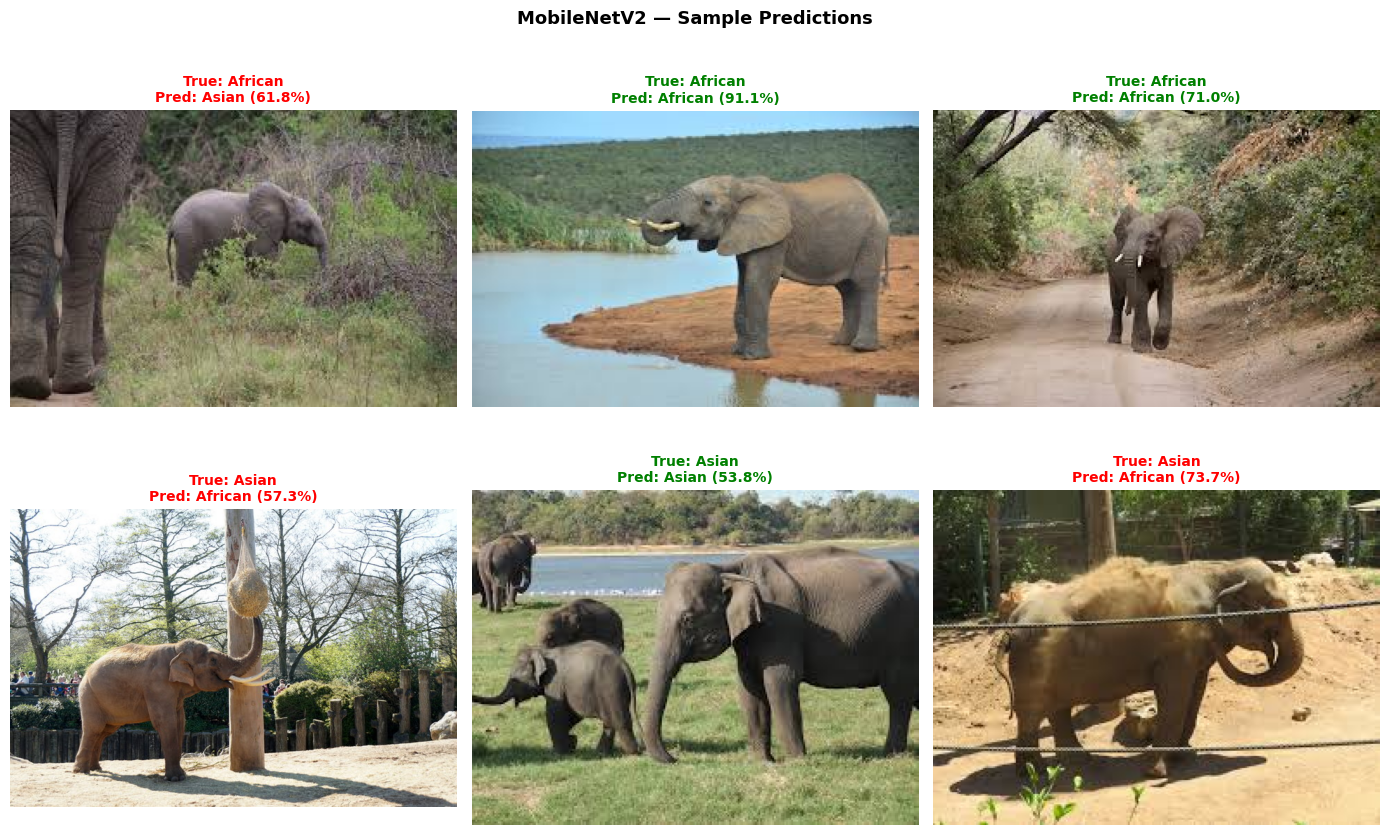

✅ Predictions plot saved → 07_sample_predictions.png


In [25]:
def predict_image(model_fn, img_path, img_size=(224,224), preprocess_fn=None):
    """Load, preprocess, predict and return (class_name, confidence)."""
    from tensorflow.keras.preprocessing import image as kimage
    img = kimage.load_img(img_path, target_size=img_size)
    x   = kimage.img_to_array(img)
    if preprocess_fn:
        x = preprocess_fn(x)
    else:
        x = x / 255.0
    x = np.expand_dims(x, axis=0)
    preds  = model_fn.predict(x, verbose=0)
    idx    = np.argmax(preds, axis=1)[0]
    return IDX_TO_CLASS[idx], float(np.max(preds)) * 100

# ── Visualise predictions on a few test images ───────────────────────────────
test_samples = []
for class_name in CLASS_INDICES.keys():
    class_dir = os.path.join(TEST_PATH, class_name)
    if os.path.isdir(class_dir):
        imgs_in_dir = [f for f in os.listdir(class_dir)
                       if f.lower().endswith(('.jpg','.jpeg','.png'))]
        for fn in imgs_in_dir[:3]:
            test_samples.append((os.path.join(class_dir, fn), class_name))

if test_samples:
    n = min(6, len(test_samples))
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    axes = axes.ravel()
    for i, (img_path, true_label) in enumerate(test_samples[:n]):
        pred_class, conf = predict_image(model_mob, img_path)
        img = plt.imread(img_path)
        axes[i].imshow(img)
        color = 'green' if pred_class == true_label else 'red'
        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_class} ({conf:.1f}%)",
            color=color, fontsize=10, fontweight='bold'
        )
        axes[i].axis('off')
    plt.suptitle('MobileNetV2 — Sample Predictions', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/07_sample_predictions.png', dpi=120)
    plt.show()
    print("✅ Predictions plot saved → 07_sample_predictions.png")
else:
    print("⚠️  No test images found — skipping inference visualisation.")


## 📦 Phase 10 — Save All Outputs & Create Final ZIP

In [26]:
# ── Copy class_indices.json to models dir too ────────────────────────────────
import shutil
shutil.copy(f'{OUTPUT_DIR}/class_indices.json', f'{MODELS_DIR}/class_indices.json')

# ── List everything that was saved ───────────────────────────────────────────
print("📂 Output directory tree:")
for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in sorted(files):
        size = os.path.getsize(os.path.join(root, f))
        print(f'{indent}  {f}  ({size/1024:.1f} KB)')


📂 Output directory tree:
outputs/
  class_indices.json  (0.0 KB)
  models/
    baseline_cnn_best.h5  (115646.9 KB)
    best_mobilenetv2.weights.h5  (25040.0 KB)
    best_mobilenetv2_hpo.weights.h5  (10201.3 KB)
    best_xception.weights.h5  (88005.3 KB)
    class_indices.json  (0.0 KB)
    mobilenetv2_best.h5  (13200.2 KB)
    xception_best.h5  (88091.3 KB)
  reports/
    cnn_report.txt  (0.4 KB)
    experiment_summary.json  (0.6 KB)
    hpo_report.txt  (0.4 KB)
    mobilenetv2_report.txt  (0.4 KB)
    xception_report.txt  (0.4 KB)
  plots/
    01_augmented_samples.png  (2725.1 KB)
    02_cnn_history.png  (88.4 KB)
    03_mob_frozen_history.png  (86.4 KB)
    04_mob_ft_history.png  (70.1 KB)
    05_xception_history.png  (65.2 KB)
    06_model_comparison.png  (64.8 KB)
    07_sample_predictions.png  (1941.4 KB)
    cnn_eval.png  (54.3 KB)
    hpo_eval.png  (55.2 KB)
    mobilenetv2_eval.png  (55.9 KB)
    xception_eval.png  (55.0 KB)


In [27]:
# ── Create ZIP archive ────────────────────────────────────────────────────────
ZIP_PATH = '/content/elephant_clf_outputs.zip'

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arc_name  = os.path.relpath(full_path, OUTPUT_DIR)
            zf.write(full_path, arc_name)

zip_size_mb = os.path.getsize(ZIP_PATH) / (1024*1024)
print(f"✅ ZIP created → {ZIP_PATH}  ({zip_size_mb:.2f} MB)")
print("\n📥 Download from the Colab Files panel or run:")
print("   from google.colab import files")
print("   files.download('/content/elephant_clf_outputs.zip')")


✅ ZIP created → /content/elephant_clf_outputs.zip  (310.75 MB)

📥 Download from the Colab Files panel or run:
   from google.colab import files
   files.download('/content/elephant_clf_outputs.zip')


In [28]:
# ── Optional: download directly ──────────────────────────────────────────────
from google.colab import files
files.download(ZIP_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ✅ Pipeline Complete

| Phase | Description | Status |
|-------|-------------|--------|
| 0 | Environment Setup & Secrets | ✅ |
| 1 | Imports & GPU Check | ✅ |
| 2 | Paths & MongoDB Connection | ✅ |
| 3 | Data Loading & Augmentation | ✅ |
| 4 | Baseline Custom CNN | ✅ |
| 5 | Transfer Learning — MobileNetV2 | ✅ |
| 6 | Hyperparameter Optimisation (KerasTuner) | ✅ |
| 7 | Transfer Learning — Xception | ✅ |
| 8 | Model Comparison & Summary | ✅ |
| 9 | Inference on Sample Images | ✅ |
| 10 | ZIP All Outputs | ✅ |

All metrics logged to **MLflow / DagsHub** and **MongoDB**.  
Model weights, plots, classification reports, and summary JSON saved in `elephant_clf_outputs.zip`.
